# 기존 방식(틱 단위 14피처) - 공정 비교용

`train_pump.ipynb`의 **피처 설계는 그대로 두고**, 데이터 조건과 학습 방식만
`Cycle_AE_v2.ipynb`와 동일하게 맞춘 버전. 이렇게 해야 "틱 단위 vs 사이클 단위"라는
차이 하나만 남고 나머지 조건이 통제된다.

**v2와 맞춘 것**
- 같은 기간: Train 9/10~9/18, Valid 9/18~9/19, Test 9/20~now
- 같은 제외 규칙: `AL_Line_Bit==1`, 매일 23:50~06:45, `Prev_SV==0`
- 같은 학습 방식: lr 0.0005 + ReduceLROnPlateau, Early Stopping, batch 64
- 같은 임계치 산출: Train 재구성오차의 99 퍼센타일 (하드코딩 4 대신)

**v2와 다른 것 (이게 비교하려는 대상)**
- 1행 = 틱 1개 (v2는 사이클 1회)
- 피처 14개 (v2는 31개)
- 블록 기준 = Wagon변경 OR BuildUp변경 (v2는 Pump_BuildUp 단독)

> 원본 `train_pump.ipynb`는 그대로 두고, 이 노트북만 별도로 돌린다.

In [1]:
import os
import sys

ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR)
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from Log_Extractor import LogExtractor
from Pump_AE import PumpAutoencoder

ENV_PATH = os.path.join(ROOT_DIR, ".env")

PUMP_ID, TANK_ID, ROBOT_ID = "P1", "P1", "RB1"

# v2와 완전히 동일한 기간
TRAIN_START, TRAIN_END = "2026-09-10T07:00:00Z", "2026-09-18T07:00:00Z"
VALID_START, VALID_END = "2026-09-18T07:00:00Z", "2026-09-19T07:00:00Z"
TEST_START,  TEST_END  = "2026-09-20T19:00:00Z", "2026-09-23T18:00:00Z"

TARGET_TAGS = [
    f"Pump_BuildUp_{PUMP_ID}", f"{ROBOT_ID}_Robot_Num",
    f"g_s_SV_{PUMP_ID}", f"Ana_Out_{PUMP_ID}",
    f"Scale_Out___PT_{PUMP_ID}", f"Scale_Out___FT_{PUMP_ID}",
    f"TK_Temp_PV_{TANK_ID}",
    "AL_Line_Bit",          # v2와 동일한 제외 규칙용
]
print(TARGET_TAGS)

['Pump_BuildUp_P1', 'RB1_Robot_Num', 'g_s_SV_P1', 'Ana_Out_P1', 'Scale_Out___PT_P1', 'Scale_Out___FT_P1', 'TK_Temp_PV_P1', 'AL_Line_Bit']


## 1. 피처 생성 — 원본 `prepare_pump_features` + v2와 동일한 제외 규칙

피처 14개의 계산식은 원본 그대로다. 달라진 건 마지막에 붙인 제외 규칙 3개뿐.

In [2]:
DAILY_EXCLUDE_START = pd.Timestamp("23:50").time()
DAILY_EXCLUDE_END = pd.Timestamp("07:00").time()


def prepare_pump_features_fair(raw_df, pump_id, tank_id, robot_id):
    """원본 train_pump.ipynb 의 prepare_pump_features 와 피처 계산식은 동일.
    마지막에 v2 와 같은 제외 규칙(AL_Line_Bit / 야간구간 / Prev_SV==0)만 추가했다."""
    df = raw_df.ffill().fillna(0).copy()
    df_reset = df.reset_index()

    tag_SV = f"g_s_SV_{pump_id}"
    tag_Ana = f"Ana_Out_{pump_id}"
    tag_PT = f"Scale_Out___PT_{pump_id}"
    tag_FT = f"Scale_Out___FT_{pump_id}"
    tag_Temp = f"TK_Temp_PV_{tank_id}"
    tag_BuildUp = f"Pump_BuildUp_{pump_id}"
    tag_Wagon = f"{robot_id}_Robot_Num"

    # --- 원본과 동일: Wagon변경 OR BuildUp변경 기준 블록 ---
    df_reset["Wagon_Changed"] = df_reset[tag_Wagon].diff() != 0
    df_reset["BuildUp_Changed"] = df_reset[tag_BuildUp].diff() != 0
    df_reset["Wagon_Block_ID"] = (df_reset["Wagon_Changed"] | df_reset["BuildUp_Changed"]).cumsum()

    shot_sv_max = df_reset[df_reset[tag_BuildUp] == 1].groupby("Wagon_Block_ID")[tag_SV].max()
    prev_sv_map = shot_sv_max.shift(1).fillna(0)
    df_reset["Prev_SV"] = df_reset["Wagon_Block_ID"].map(prev_sv_map).ffill().fillna(0)
    df_reset["Prev_SV_Diff"] = df_reset[tag_SV] - df_reset["Prev_SV"]

    df_reset["Instant_SV_Diff"] = df_reset[tag_SV].diff().fillna(0)
    df_reset["Phase_Transition"] = np.where(df_reset["Instant_SV_Diff"] != 0, 1.0, 0.0)
    df_reset["Rolling_PT_Max_3"] = df_reset[tag_PT].rolling(window=3, min_periods=1).max()
    df_reset["Rolling_PT_Diff_3"] = df_reset[tag_PT].diff(periods=2).fillna(0)

    df_shots = df_reset[df_reset[tag_BuildUp] == 1].copy()
    model_df = df_shots.copy()

    model_df["Tick_Index"] = model_df.groupby("Wagon_Block_ID").cumcount()
    model_df["Phase_Start"] = np.where(model_df["Tick_Index"] < 2, 1.0, 0.0)
    model_df["Phase_Steady"] = np.where(model_df["Tick_Index"] >= 2, 1.0, 0.0)

    model_df["Instant_FT_Error"] = model_df[tag_SV] - model_df[tag_FT]
    model_df["Instant_FT_Error_Rate"] = np.where(
        model_df[tag_SV] > 0, (model_df["Instant_FT_Error"] / model_df[tag_SV]) * 100, 0)
    model_df["Cum_FT_Error"] = model_df.groupby("Wagon_Block_ID")["Instant_FT_Error"].cumsum()

    # ===== 여기부터가 v2 와 맞춘 제외 규칙 =====
    n0 = len(model_df)
    time_col = model_df[model_df.columns[0]] if "Time" not in model_df.columns else model_df["Time"]
    tod = pd.to_datetime(time_col).dt.time

    if "AL_Line_Bit" in model_df.columns:
        mask_alarm = model_df["AL_Line_Bit"] > 0
    else:
        mask_alarm = pd.Series(False, index=model_df.index)
    mask_night = (tod >= DAILY_EXCLUDE_START) | (tod <= DAILY_EXCLUDE_END)
    mask_cold = model_df["Prev_SV"] == 0

    keep = ~(mask_alarm.values | mask_night.values | mask_cold.values)
    model_df = model_df[keep]
    print(f"    제외: 알람 {int(mask_alarm.sum())} / 야간 {int(mask_night.sum())} / "
          f"Prev_SV==0 {int(mask_cold.sum())} → {n0:,} → {len(model_df):,}틱")

    feature_cols = [
        tag_SV, "Prev_SV", "Prev_SV_Diff",
        tag_Ana, tag_Temp,
        tag_PT, "Rolling_PT_Max_3", "Rolling_PT_Diff_3",
        tag_FT, "Instant_FT_Error_Rate", "Cum_FT_Error",
        "Phase_Start", "Phase_Steady", "Phase_Transition",
    ]
    model_df = model_df.fillna(0)
    return model_df[feature_cols], feature_cols


print("준비 완료")

준비 완료


## 2. 데이터 추출

In [3]:
extractor = LogExtractor(env_path=ENV_PATH)

def build(start, end, label):
    raw = extractor.get_data(start_time=start, end_time=end, target_tags=TARGET_TAGS)
    feats, fcols = prepare_pump_features_fair(raw, PUMP_ID, TANK_ID, ROBOT_ID)
    print(f"[{label}] raw {len(raw):,}행 → 틱 {len(feats):,}개")
    return feats, fcols

train_df, feature_cols = build(TRAIN_START, TRAIN_END, "Train")
valid_df, _ = build(VALID_START, VALID_END, "Valid")
test_df,  _ = build(TEST_START,  TEST_END,  "Test")
print(f"\n피처 {len(feature_cols)}개: {feature_cols}")

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!
🚀 추출 시작: 2026-09-10T07:00:00+00:00 ~ 2026-09-18T07:00:00+00:00
   태그 8개 · 앞쪽 600초는 결측 복원용으로 더 받습니다
📦 [Chunk] 2026-09-10T06:50:00Z ~ 2026-09-10T12:50:00Z ... 

39314행
📦 [Chunk] 2026-09-10T12:50:00Z ~ 2026-09-10T18:50:00Z ... 

35937행
📦 [Chunk] 2026-09-10T18:50:00Z ~ 2026-09-11T00:50:00Z ... 

37014행
📦 [Chunk] 2026-09-11T00:50:00Z ~ 2026-09-11T06:50:00Z ... 

38124행
📦 [Chunk] 2026-09-11T06:50:00Z ~ 2026-09-11T12:50:00Z ... 

...

35625행
📦 [Chunk] 2026-09-22T18:50:00Z ~ 2026-09-23T00:50:00Z ... 

36069행
📦 [Chunk] 2026-09-23T00:50:00Z ~ 2026-09-23T02:01:02Z ... 

7631행


✅ 통합 완료 — 342707행 × 9컬럼
🌡️  온도 계열 컬럼 1개 — **단위가 태그마다 다르다.**
     TK_Temp_PV_P1            Scale_Max___TT_P1=1000 → 0.1℃ 단위, 값÷10
     ※ 2026-04 데이터는 Scale_Max___TT_P1=100 이었다. 지금은 1000 이라
       같은 태그가 22 → 228 로 찍힌다. 두 시기를 섞지 말 것.


    제외: 알람 0 / 야간 2429 / Prev_SV==0 20 → 110,039 → 107,610틱
[Test] raw 342,707행 → 틱 107,610개

피처 14개: ['g_s_SV_P1', 'Prev_SV', 'Prev_SV_Diff', 'Ana_Out_P1', 'TK_Temp_PV_P1', 'Scale_Out___PT_P1', 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', 'Scale_Out___FT_P1', 'Instant_FT_Error_Rate', 'Cum_FT_Error', 'Phase_Start', 'Phase_Steady', 'Phase_Transition']


## 3. 스케일링 + 학습 (v2와 동일한 방식)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df)
X_valid = scaler.transform(valid_df)
X_test = scaler.transform(test_df)
print(X_train.shape, X_valid.shape, X_test.shape)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(X_train)),
                          batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(torch.FloatTensor(X_valid), torch.FloatTensor(X_valid)),
                          batch_size=64, shuffle=False)

(323111, 14) (45357, 14) (107610, 14)


In [5]:
torch.manual_seed(42)
model = PumpAutoencoder(len(feature_cols))   # 원본 구조 그대로 (14 -> 8 -> 4 -> 8 -> 14)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)             # v2와 동일
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

EPOCHS, PATIENCE = 200, 30
best_val, best_epoch, wait = float("inf"), 0, 0
best_state, hist = None, []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr += loss.item()
    tr /= len(train_loader)

    model.eval()
    va = 0.0
    with torch.no_grad():
        for xb, yb in valid_loader:
            va += criterion(model(xb), yb).item()
    va /= len(valid_loader)
    scheduler.step(va)
    hist.append((epoch, tr, va, optimizer.param_groups[0]["lr"]))

    if va < best_val - 1e-5:
        best_val, best_epoch, wait = va, epoch, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    if epoch % 10 == 0 or epoch == 1:
        star = "  *best*" if best_epoch == epoch else ""
        print(f"Epoch {epoch:03d} | Train {tr:.4f} | Valid {va:.4f} | "
              f"lr {optimizer.param_groups[0]['lr']:.1e}{star}")

    if wait >= PATIENCE:
        print(f"\nEarly stopping (epoch {epoch}, best={best_epoch})")
        break

model.load_state_dict(best_state)
print(f"\n최종 best Valid Loss: {best_val:.4f} (epoch {best_epoch})")

Epoch 001 | Train 0.2397 | Valid 0.1390 | lr 5.0e-04  *best*


Epoch 010 | Train 0.0737 | Valid 0.0918 | lr 5.0e-04


Epoch 020 | Train 0.0707 | Valid 0.1081 | lr 2.5e-04


Epoch 030 | Train 0.0702 | Valid 0.1072 | lr 1.3e-04



Early stopping (epoch 36, best=6)

최종 best Valid Loss: 0.0869 (epoch 6)


## 4. 재구성오차 & 임계치 (v2와 동일하게 Train 99퍼센타일)

In [6]:
def recon_error(X):
    model.eval()
    with torch.no_grad():
        t = torch.FloatTensor(X)
        pf = (t - model(t)) ** 2
        return pf.mean(dim=1).numpy(), pf.numpy()

train_err, train_pf = recon_error(X_train)
valid_err, _ = recon_error(X_valid)
test_err, test_pf = recon_error(X_test)

THRESHOLD = float(np.percentile(train_err, 99))
print(f"임계치 (Train 99퍼센타일): {THRESHOLD:.4f}\n")
for name, err in [("Train", train_err), ("Valid", valid_err), ("Test", test_err)]:
    over = err > THRESHOLD
    print(f"{name:6s} | 평균 {err.mean():.4f} | 중앙값 {np.median(err):.4f} | "
          f"최대 {err.max():.4f} | 임계치 초과 {over.sum():,}건 ({over.mean()*100:.2f}%)")

임계치 (Train 99퍼센타일): 0.6180

Train  | 평균 0.0833 | 중앙값 0.0495 | 최대 2.7853 | 임계치 초과 3,232건 (1.00%)
Valid  | 평균 0.0869 | 중앙값 0.0534 | 최대 3.1623 | 임계치 초과 315건 (0.69%)
Test   | 평균 0.1023 | 중앙값 0.0599 | 최대 2.2028 | 임계치 초과 1,454건 (1.35%)


## 5. 범인 색출 — 무엇이 이상으로 잡히는가

핵심 질문: 조건을 맞춰도 `Phase_Transition`(SV 변경)이 계속 1위인가?

In [7]:
order = np.argsort(-test_err)
top = order[:200]

from collections import Counter
cnt = Counter()
for pos in top:
    contrib = pd.Series(test_pf[pos], index=feature_cols)
    for f in contrib.nlargest(3).index:
        cnt[f] += 1

print("상위 이상 200건의 Top3 범인 등장 횟수")
for f, n in cnt.most_common():
    print(f"  {f:28s} {n:4d}회  ({n/200*100:.1f}%)")

print("\n상위 5건 상세")
for rank, pos in enumerate(order[:5], 1):
    contrib = pd.Series(test_pf[pos], index=feature_cols)
    contrib = (contrib / contrib.sum() * 100).sort_values(ascending=False)
    print(f"[#{rank}] 오차 {test_err[pos]:.3f}")
    for f, v in contrib.head(3).items():
        print(f"      - {f}: {v:.1f}%")

상위 이상 200건의 Top3 범인 등장 횟수
  Phase_Transition              184회  (92.0%)
  Scale_Out___PT_P1             115회  (57.5%)
  Rolling_PT_Max_3              110회  (55.0%)
  TK_Temp_PV_P1                  81회  (40.5%)
  Rolling_PT_Diff_3              64회  (32.0%)
  Phase_Start                    35회  (17.5%)
  g_s_SV_P1                       6회  (3.0%)
  Scale_Out___FT_P1               1회  (0.5%)
  Instant_FT_Error_Rate           1회  (0.5%)
  Cum_FT_Error                    1회  (0.5%)
  Ana_Out_P1                      1회  (0.5%)
  Prev_SV                         1회  (0.5%)

상위 5건 상세
[#1] 오차 2.203
      - Phase_Transition: 21.0%
      - Scale_Out___PT_P1: 16.7%
      - Rolling_PT_Max_3: 16.5%
[#2] 오차 1.988
      - TK_Temp_PV_P1: 45.4%
      - Phase_Transition: 40.9%
      - Rolling_PT_Diff_3: 4.6%
[#3] 오차 1.835
      - TK_Temp_PV_P1: 51.1%
      - Phase_Transition: 35.3%
      - Phase_Start: 3.2%
[#4] 오차 1.828
      - TK_Temp_PV_P1: 53.3%
      - Phase_Transition: 28.5%
      - Phase_Start: 5.0

## 6. 피처별 재구성 난이도 (v2와 같은 기준)

Phase_Steady             0.013813
Phase_Start              0.013814
g_s_SV_P1                0.039500
Ana_Out_P1               0.040104
Scale_Out___FT_P1        0.053269
Phase_Transition         0.054967
Rolling_PT_Max_3         0.064231
Scale_Out___PT_P1        0.073872
Rolling_PT_Diff_3        0.077530
Instant_FT_Error_Rate    0.078563
Prev_SV_Diff             0.117611
Cum_FT_Error             0.144957
TK_Temp_PV_P1            0.161514
Prev_SV                  0.233021


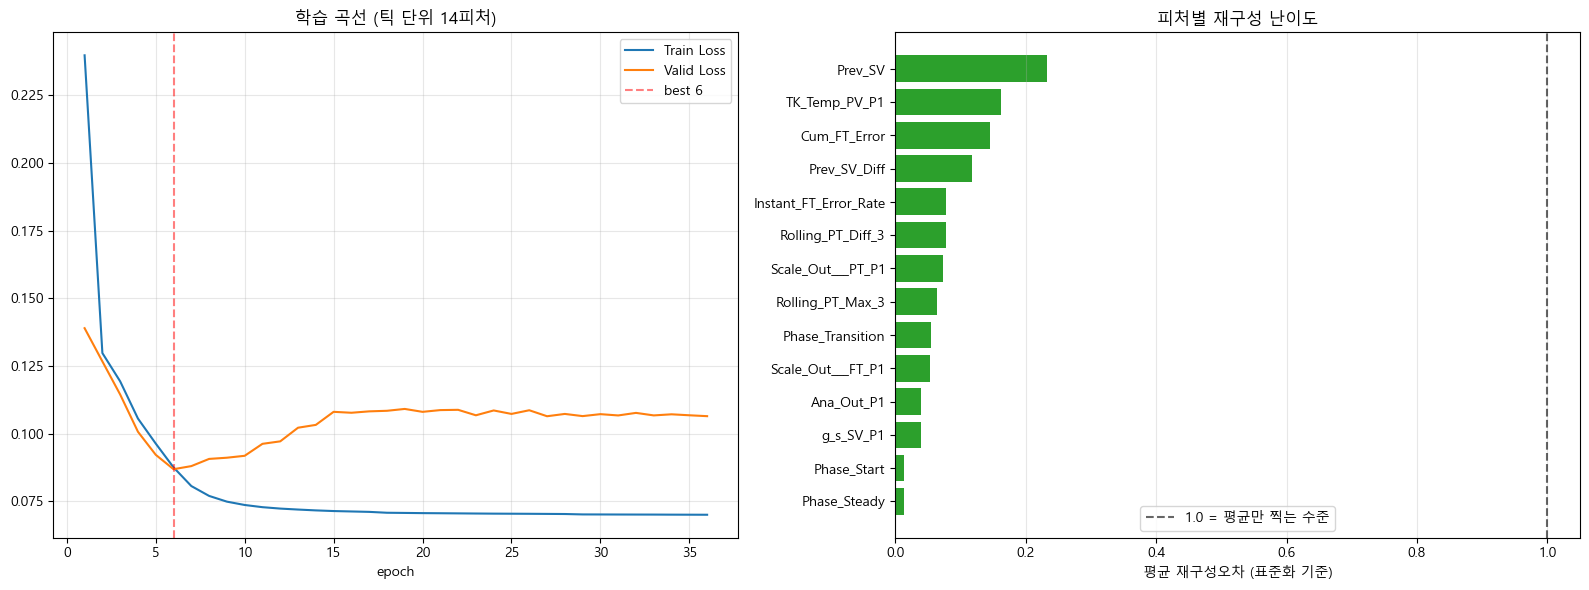

In [8]:
per_feat = pd.Series(train_pf.mean(axis=0), index=feature_cols).sort_values()
print(per_feat.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

h = pd.DataFrame(hist, columns=["epoch", "train", "valid", "lr"])
axes[0].plot(h["epoch"], h["train"], label="Train Loss")
axes[0].plot(h["epoch"], h["valid"], label="Valid Loss")
axes[0].axvline(best_epoch, color="red", ls="--", alpha=.5, label=f"best {best_epoch}")
axes[0].set_title("학습 곡선 (틱 단위 14피처)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=.3)

colors = ["tab:green" if v < 0.3 else "tab:orange" if v < 0.7 else "tab:red" for v in per_feat.values]
axes[1].barh(per_feat.index, per_feat.values, color=colors)
axes[1].axvline(1.0, color="black", ls="--", alpha=.6, label="1.0 = 평균만 찍는 수준")
axes[1].set_title("피처별 재구성 난이도")
axes[1].set_xlabel("평균 재구성오차 (표준화 기준)")
axes[1].legend()
axes[1].grid(axis="x", alpha=.3)

plt.tight_layout()
plt.show()